# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 

### The Traveling Salesman Problem

The traveling salesman problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

Consider now the ordered sequence of cities, $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, which goes from city 1 to the n$^{th}$ city. The path that minimizes the following loss/cost function:

$$
L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|^2
$$

or 
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$


(with $\vec{x}_{N+1}=\vec{x}_1$) is one particular permutation, P, of the ordered sequence of cities $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, i.e. 

$$
\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N = \vec{c}_{P1}, \vec{c}_{P2}, \dots, \vec{c}_{PN}
$$

Note also that any particular permutation of the ordered sequence of cities can be obtained from the combination of many simple permutations among pairs of cities.

We can express a possible path via a 1D vector whose elements, from the first to the last, are integers that represents the cities in the order in which the salesman would visit them; for example for $N=5$ cities one possible path is represented by the vector:

$$
\left[ 1, 3, 5, 4, 2 \right]
$$

**Alteratively**, we can express a possible path also via a configuration of a $N\times N$ 2D *Ising-like* model with the following bonds:
1. any row must have one and at most one up spin
2. any column must have one and at most one up spin,

all the other spins are down.

We can represent such a configuration with a $N\times N$ matrix whose elements are 1 (spin up) or 0 (spin down); for example, in the case of a TSP with 5 cities:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 1 & 0\\
0 & 0 & 1 & 0 & 0\\
\end{bmatrix}
$$

You can interpret this matrix in the following way:
- column index represents time of visit: first colum = first visit, etc.
- row index represents the ordered sequence of cities: first row = first city, etc.

the previous matrix thus refers to the following sequence:

$$
\vec{x}_1, \vec{x}_2, \vec{x}_3, \vec{x}_4, \vec{x}_5 = 
\vec{c}_{1}, \vec{c}_{3}, \vec{c}_{5}, \vec{c}_{4}, \vec{c}_{2}
$$

and thus to the following *cost* of the path:

$$
L^{(2)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3|^2 + |\vec{c}_3-\vec{c}_5|^2 + |\vec{c}_5-\vec{c}_4|^2 +
|\vec{c}_4-\vec{c}_2|^2 + |\vec{c}_2-\vec{c}_1|^2
$$

or
$$
L^{(1)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3| + |\vec{c}_3-\vec{c}_5| + |\vec{c}_5-\vec{c}_4| +
|\vec{c}_4-\vec{c}_2| + |\vec{c}_2-\vec{c}_1|
$$


Note that, for this *ising-like* representation any particular permutation of the ordered sequence of cities can be obtained by a sequence of multiple pair permutations among rows and/or among columns.

**Warm suggestion: by using the 1D representation** (but you can work with the representation you prefer or the one you are able to invent) ...


### Exercise 09.1

Write a code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.

You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population with $M$ individuals, e.g. select the individual $j$ with the algorithm: $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Set the first city to always appear at position 1, so as to reduce the degeneration of the shortest route to be 2, which corresponds to walking the shortest route in clockwise and anti-clockwise directions.

Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bonds and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 34 cities randomly placed **on** a circumference
- 34 cities randomly placed **inside** a square

Show your results via:

- a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm
- a picture of the best path in cartesian coordinates

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection
plt.style.use('default')

color=plt.cm.viridis(0.3)
color2=plt.cm.viridis(0.5)

### Implementation
In questa esercitazione viene implementato un algoritmo genetico (GA) per risolvere il problema del commesso viaggiatore (TSP) su due distribuzioni di città (cerchio e quadrato). Il codice è suddiviso in tre file principali:

- **individual.cpp / individual.h**: definisce la classe `Individual`, che rappresenta un singolo percorso (individuo) e i suoi operatori genetici.
- **population.cpp / population.h**: definisce la classe `Population`, che gestisce l’insieme di individui, la selezione, il crossover, le mutazioni e l’evoluzione generazionale.
- **main.cpp**: imposta il generatore di numeri casuali, i parametri del GA e lancia due esperimenti (cerchio e quadrato).

### Classe Individual

1. **Attributi principali:**

- `int _num_of_cities`  
- `arma::mat _distance_matrix` — matrice simmetrica delle distanze fra le città.  
- `arma::uvec _path` — vettore di lunghezza `N` che contiene un permutazione delle città (la prima sempre 0).  
- `double _fitness` — lunghezza totale del percorso (da minimizzare).

2. **Costruttore:**

```cpp
Individual::Individual(int num_of_cities, const mat &distance_matrix) {
  _num_of_cities = num_of_cities;
  _distance_matrix = distance_matrix;
  _path.set_size(_num_of_cities);
}
```

3. **Inizializzazione Casuale:**
```cpp
void Individual::Initialize(Random &rnd) {
  // path iniziale [0,1,2,…,N−1]
  for(int i=0; i<_num_of_cities; i++) _path(i) = i;
  // mescolo (escludendo la posizione 0) con semplici swap casuali
  for(int i=0; i<_num_of_cities; i++) {
    int j = rnd.Rannyu(1,_num_of_cities);
    int k = rnd.Rannyu(1,_num_of_cities);
    Swap(j,k);
  }
  Check();    // validità del percorso
  Fitness();  // calcolo fitness
}
```

4. **Controllo di validità:**
```cpp
void Individual::Check() {
  // la prima città deve essere 0 e tutte le città devono comparire una sola volta
  if(_path(0) != 0)    error_exit();
  if(unique(_path).n_elem != _num_of_cities) error_exit();
}
```

5. **Calcolo del Fitness:**
```cpp
void Individual::Fitness() {
  double dist = 0.;
  for(int i=0; i<_num_of_cities-1; i++)
    dist += _distance_matrix(_path(i), _path(i+1));
  // aggiungo il ritorno alla città 0
  dist += _distance_matrix(_path(_num_of_cities-1), _path(0));
  _fitness = dist;
}
```

6. **Operatori genetici (mutazioni):**
Tutti eccetto swap escludono la prima città (indice 0).

- Pair Permutation (scambio di due città casuali)
    ```cpp
    void PairPermutation(Random & rnd);
    ```

- Shift (scorrimento di un blocco di blk città di l posizioni)
    ```cpp
    void Shift(Random & rnd);
    ```

- Adjacent Permutation (scambio di due blocchi contigui di lunghezza blk)
    ```cpp
    void AdiacentPermutation(Random & rnd);
    ```

- Inversion (inversione di un sotto-vettore di lunghezza j)
    ```cpp
    void Inversion(Random & rnd);
    ```

- Swap (scambio di due posizioni generico)
    ```cpp
    void Swap(int i, int j);
    ```

- SetPath (forza un nuovo percorso, ricalcola check e fitness)
    ```cpp
    void SetPath(const arma::uvec & path);
    ```


### Classe Population

1. **Attributi principali:**

- `Random * _rnd`  — puntatore al generatore di numeri casuali.
- `string _type` — “circle” o “square”. 
- `int _num_of_cities, _npop, _ngen;` 
- `double _mut_prob, _p_exponent;` 
- `arma::mat _pos` - coordinate della città (Nx2). 
- `arma::mat _distance_matrix` - distanze pre calcolate.
- `vector<Individual> _individuals` - popolazione corrente. 
- `ofstream _loss` — file di output per l’andamento del fitness.
- `int _gen_index` — contatore di generazione.

2. **Inizializzazione**

```cpp
void Population::Initialize(Random & rnd, const string & type,
                            int num_of_cities, int npop, int ngen,
                            double mut_prob, double p_exp) {
  // memorizzo parametri
  _rnd = &rnd;  _type = type;
  _num_of_cities = num_of_cities; _npop = npop; _ngen = ngen;
  _mut_prob = mut_prob; _p_exponent = p_exp; _gen_index = 0;
  _pos.set_size(_num_of_cities,2);

  // imposto i punti su cerchio o quadrato
  if(_type=="circle")    InitializeCircle();
  else if(_type=="square") InitializeSquare();

  // calcolo matrice delle distanze
  CreateDistanceMatrix();

  // creo popolazione iniziale
  for(int i=0; i<_npop; i++) {
    Individual ind(_num_of_cities, _distance_matrix);
    ind.Initialize(rnd);
    _individuals.push_back(ind);
  }
  FitnessSorting();

  // apro file di log
  _loss.open(_type + "_losses.dat");
  cout << "Optimization: " << _type << endl;
}
```

Le città vengono posizionate uniformemente su una circonferenza o un quadrato attraverso InitializeCircle() e InitializeSquare().

3. **Creazione matrice delle distanze:**
```cpp
void Population::CreateDistanceMatrix() {
  _distance_matrix.set_size(_num_of_cities,_num_of_cities);
  for(int i=0; i<_num_of_cities; i++)
    for(int j=i+1; j<_num_of_cities; j++) {
      double d = norm(_pos.row(i)-_pos.row(j));
      _distance_matrix(i,j) = _distance_matrix(j,i) = d;
    }
}
```

4. **Ordinamento per fitness:**
```cpp
void Population::FitnessSorting() {
  sort(_individuals.begin(), _individuals.end(),
       [](auto &a, auto &b){ return a.GetFitness() < b.GetFitness(); });
}
```

5. **Selezione Rank-Biased:**
```cpp
Individual Population::SelectRank() {
  int idx = int(_npop * pow(_rnd->Rannyu(), _p_exponent));
  return _individuals[idx];
}
```

6. **Crossover (order-preserving):**
```cpp
void Population::Crossover(Individual &p1, Individual &p2,
                           Individual &c1, Individual &c2) {
  auto x1 = p1.GetPath(), x2 = p2.GetPath();
  int cut = int(_rnd->Rannyu(1,_num_of_cities-1));
  arma::uvec sec1(_num_of_cities), sec2(_num_of_cities);
  // copio la parte [0..cut]
  for(int i=0; i<=cut; i++){
    sec1(i)=x1(i); sec2(i)=x2(i);
  }
  // riempio il resto con l’ordine sparso dell’altro genitore
  int i1=cut+1, i2=cut+1;
  for(int i=0; i<_num_of_cities; i++){
    if(!contains(sec1.head(cut+1), x2(i))) sec1(i1++)=x2(i);
    if(!contains(sec2.head(cut+1), x1(i))) sec2(i2++)=x1(i);
  }
  c1.SetPath(sec1);
  c2.SetPath(sec2);
}
```

7. **Nuova generazione:**
```cpp
void Population::NewGeneration() {
  vector<Individual> next; next.reserve(_npop);
  while(next.size() < _npop) {
    // seleziono due genitori
    Individual p1 = SelectRank(), p2 = SelectRank();
    Individual c1(_num_of_cities,_distance_matrix),
               c2(_num_of_cities,_distance_matrix);
    // crossover o copia diretta
    if(_rnd->Rannyu()<0.7) Crossover(p1,p2,c1,c2);
    else {
      c1.SetPath(p1.GetPath());
      c2.SetPath(p2.GetPath());
    }
    // mutazioni con probabilità _mut_prob
    if(_rnd->Rannyu()<_mut_prob) c1.PairPermutation(*_rnd);
    if(_rnd->Rannyu()<_mut_prob) c1.Shift(*_rnd);
    if(_rnd->Rannyu()<_mut_prob) c1.AdiacentPermutation(*_rnd);
    if(_rnd->Rannyu()<_mut_prob) c1.Inversion(*_rnd);
    // idem per c2…
    c1.Fitness(); c2.Fitness();

    next.push_back(c1);
    if(next.size()<_npop) next.push_back(c2);
  }
  _individuals = move(next);
  FitnessSorting();

  // log dei risultati
  double best = _individuals[0].GetFitness();
  double avg50 = GetBestHalfAvg();
  _loss << _gen_index << "\t" << best << "\t" << avg50 << "\n";
  if(_gen_index%100==0)
    cout<< _type<<" gen "<<_gen_index<<" best="<<best<<endl;
  _gen_index++;
}
```

8. **Output e chiusura:**
```cpp
void Population::Closure() {
  // scrive percorso migliore su file *_best_path.dat
  auto best_path = _individuals[0].GetPath();
  ofstream out(_type + "_best_path.dat");
  for(int i=0; i<_num_of_cities; i++){
    int j = best_path(i);
    out << _pos(j,0) << "\t" << _pos(j,1) << "\n";
  }
  // richiusura del ciclo
  out << _pos(best_path(0),0) << "\t" << _pos(best_path(0),1) << "\n";
  out.close();
  cout << "\nBest path found for " << _type << ".\n\n";
}
```

### Output
Vengono creati i seguenti files di ouput:
- circle_losses.dat / square_losses.dat (colonne: generazione, best fitness, media del 50% migliore).
- circle_best_path.dat / square_best_path.dat (coordinate (x,y) del percorso ottimo, chiuso sulla prima città).

### Sintesi
L’implementazione, in sintesi, sfrutta:

- una classe Individual per gestire permutazioni e mutazioni;
- una classe Population per orchestrare selezione, crossover, mutazione ed evoluzione;
- un’interfaccia main minimale per lanciare due esperimenti comparativi su distribuzioni di città diverse.

Il codice è modulare e permette di sperimentare facilmente nuovi operatori genetici, strategie di selezione e criteri di fitness.


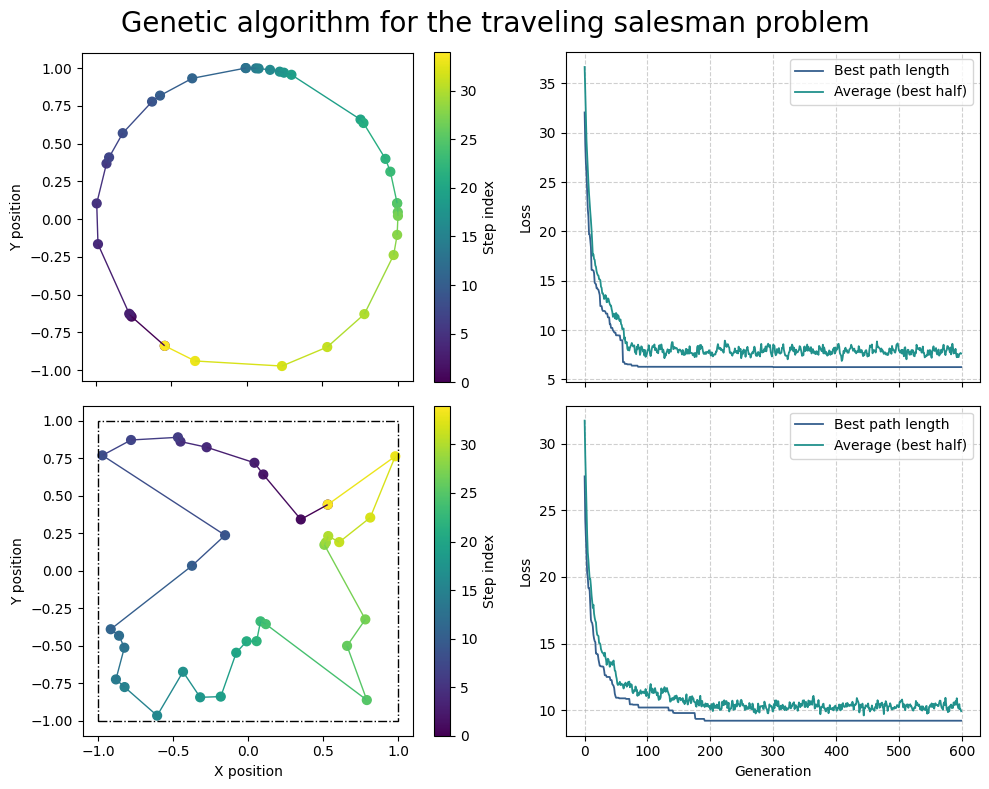

In [7]:

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

data = np.loadtxt("ex09.1/circle_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', linewidth=1, array=np.arange(len(x)))
axs[0,0].add_collection(lc)

sc = axs[0,0].scatter(x, y, c=np.arange(len(x)), cmap='viridis', s=40)
axs[0,0].set_aspect('equal')
axs[0,0].set_ylabel('Y position')
axs[0,0].tick_params(axis='x', labelbottom=False)
fig.colorbar(sc, ax=axs[0,0], label="Step index") 

data = np.loadtxt("ex09.1/circle_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[0,1].plot(gen, best, label="Best path length", linewidth=1.3, color=color)
axs[0,1].plot(gen, avg, label="Average (best half)", linewidth=1.3, color=color2)
axs[0,1].legend()
axs[0,1].set_ylabel('Loss')
axs[0,1].tick_params(axis='x', labelbottom=False)
axs[0,1].grid(True, linestyle='--', alpha=0.6)

data = np.loadtxt("ex09.1/square_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', linewidth=1, array=np.arange(len(x)))
axs[1,0].add_collection(lc)

sc = axs[1,0].scatter(x, y, c=np.arange(len(x)), cmap='viridis', s=40)
axs[1,0].set_aspect('equal')
axs[1,0].set_xlabel('X position')
axs[1,0].set_ylabel('Y position')
fig.colorbar(sc, ax=axs[1,0], label="Step index")  

data = np.loadtxt("ex09.1/square_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[1,1].plot(gen, best, label="Best path length", linewidth=1.3, color=color)
axs[1,1].plot(gen, avg, label="Average (best half)", linewidth=1.3, color=color2)
axs[1,1].set_ylabel('Loss')
axs[1,1].set_xlabel('Generation')
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.6)
square = Rectangle((-1, -1), 2, 2,
                   fill=False,
                   edgecolor='black',
                   linestyle='-.',
                   linewidth=1)

axs[1,0].add_patch(square)

plt.suptitle("Genetic algorithm for the traveling salesman problem", fontsize=20)
plt.tight_layout()
plt.show()